In [37]:
import polars as pl
import plotly.express as px
import plotly.graph_objects as go
import colorir as cl
from analyses import io

In [38]:
colors = cl.StackPalette.load("safe")

/var/folders/w1/yk1qychd0w18s7yt7v2x0rd00000gn/T/ipykernel_23360/1286076443.py:1: FutureWarning:

'config.DEFAULT_PALETTES_DIR' is going to change to the current directory on the next minor release, specify 'palettes_dir=colorir.config.USR_PALETTES_DIR' to disable this warning



In [29]:
celldf = io.read_celldfs(
    "../runs/invading/", 
    levels=["replica", "cell_energy", "mul_energy"]
).with_columns(
    pl.col("cell_energy").str.strip_prefix("cell_energy-").cast(pl.UInt32),
    pl.col("mul_energy").str.strip_prefix("mul_energy-").cast(pl.UInt32),
    pl.col("replica").cast(pl.UInt32),
    displ=(pl.col("center_x") ** 2 + pl.col("center_y") ** 2) ** 0.5
)
celldf

index,ancestor,area,target_area,perimeter,target_perimeter,center_x,center_y,chem_center_x,chem_center_y,chem_mass,ligands,receptors,neighbors,neighbor_contacts,neighbor_gammas,med_neighbor,solid_neighbor,tot_act,tot_kact,lineage,time,wtime,replica,cell_energy,mul_energy,displ
u32,u32,u32,u32,u32,u32,f32,f32,f32,f32,u32,u64,u64,str,str,str,bool,bool,u32,f64,str,u32,u32,u32,u32,u32,f32
0,0,196,200,164,180,66.499962,395.5,66.491653,395.44812,60151,69,224,"""m""","""164""","""0""",true,false,3920,3920.0,"""mul""",0,0,0,13,12,401.051727
1,1,196,200,164,180,235.500031,114.500008,235.467224,114.483971,87435,10,133,"""m""","""164""","""0""",true,false,3920,3920.0,"""mul""",0,0,0,13,12,261.859711
2,2,196,200,164,180,86.499962,101.500008,86.481575,101.478447,112618,9,79,"""m""","""164""","""0""",true,false,3920,3920.0,"""mul""",0,0,0,13,12,133.358521
3,3,196,200,164,180,306.500031,360.5,306.454987,360.44751,46020,165,100,"""m""","""164""","""0""",true,false,3920,3920.0,"""mul""",0,0,0,13,12,473.18338
4,4,196,200,164,180,423.500031,377.5,423.413452,377.422729,27568,69,78,"""m""","""164""","""0""",true,false,3920,3920.0,"""mul""",0,0,0,13,12,567.325745
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
95,95,200,200,188,180,230.724701,64.463478,230.623047,64.401215,93683,144,37,"""m 94""","""166 22""","""0 0""",true,false,280,91.849239,"""uni""",5000000,5000000,4,20,18,239.560898
96,96,201,200,184,180,37.237663,93.048332,37.25235,93.070839,122139,37,115,"""m""","""184""","""0""",true,false,624,426.90922,"""uni""",5000000,5000000,4,20,18,100.222931
97,97,200,200,180,180,156.431351,131.9422,156.392365,131.958145,100667,44,200,"""m 41""","""166 14""","""0 0""",true,false,448,131.701613,"""uni""",5000000,5000000,4,20,18,204.644836


In [31]:
grouppers = ["mul_energy", "cell_energy"]
clusterdf = celldf.filter(pl.col("wtime") >= 4e6, lineage="mul").group_by(grouppers).agg(
    cluster_x=pl.col("center_x").mean(),
    cluster_y=pl.col("center_y").mean(),
    cluster_displ=pl.col("displ").mean()
).sort(grouppers)
clusterdf

mul_energy,cell_energy,cluster_x,cluster_y,cluster_displ
u32,u32,f32,f32,f32
12,13,213.571243,198.274475,313.875183
12,14,241.000717,232.256424,360.426514
12,15,262.349976,253.892639,389.029053
12,16,268.792053,261.984283,399.590454
12,17,275.764648,282.961517,416.841736
…,…,…,…,…
16,18,247.808472,253.933243,380.446777
16,19,261.147888,278.847717,409.323364
16,20,265.783722,268.934235,402.027924


In [32]:
pvdf = clusterdf.pivot(on="mul_energy", index="cell_energy", values="cluster_displ")
pvdf

cell_energy,12,14,16,18
u32,f32,f32,f32,f32
13,313.875183,null,null,null
14,360.426514,null,null,null
15,389.029053,399.160187,null,null
16,399.590454,390.555756,null,null
17,416.841736,417.629883,399.857086,null
18,403.70636,397.314972,380.446777,null
19,402.431671,402.686707,409.323364,421.48584
20,410.272583,392.566864,402.027924,393.692627


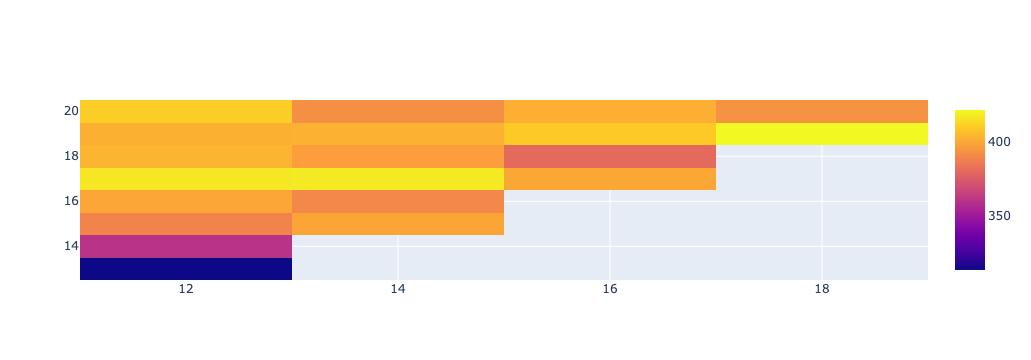

In [33]:
go.Figure(go.Heatmap(
    z=pvdf.drop("cell_energy").to_numpy(),
    x=pvdf.columns[1:],
    y=pvdf["cell_energy"]
))

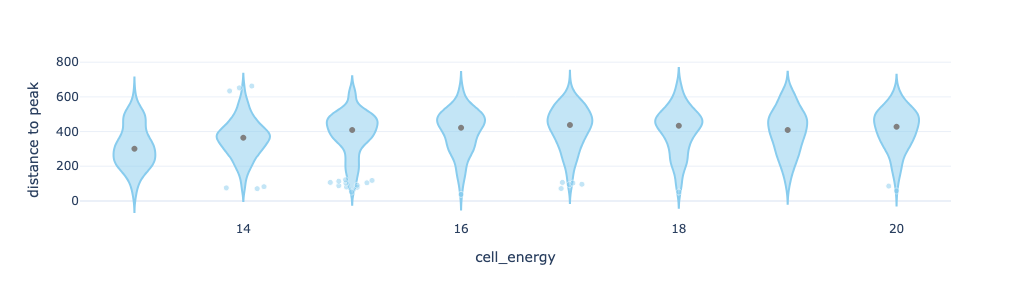

In [54]:
filterdf = celldf.filter(
    pl.col("wtime") >= 4e6,
    lineage="mul",
    mul_energy=12,
)
px.violin(
    filterdf,
    x="cell_energy",
    y="displ"
).update_traces(
    jitter=1,
    marker_line_width=1,
    marker_line_color="white",
    marker_opacity=0.5,
    marker_color=colors[0]
).add_traces(
    px.scatter(
        filterdf.group_by("cell_energy").median(),
        x="cell_energy",
        y="displ"
    ).update_traces(
        marker_color="gray"
    ).data
).update_layout(
    template="plotly_white",
    width=400,
    height=300,
    showlegend=False,
    xaxis_dtick=2,
    # yaxis_range=[0, max_chem],
    yaxis_title="distance to peak"
)